In [ ]:
!pip install -q addict simplejson yapf gast oss2 sortedcontainers requests
!pip install -q modelscope transformers>=4.37.0 datasets torch torchvision \
    accelerate scikit-learn sentencepiece Pillow matplotlib evaluate optimum[exporters]

import torch, os, sys, json, warnings, numpy as np
warnings.filterwarnings("ignore")

import addict; print("✅ addict OK")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

import modelscope
print(f"ModelScope: {modelscope.__version__}")

DEVICE = 0 if torch.cuda.is_available() else -1


from modelscope import snapshot_download
from modelscope.hub.api import HubApi

api = HubApi()
print("\n🔍 Searching ModelScope Hub for 'bert' models...\n")
try:
    models = api.list_models(filter_dict={"Search": "bert"}, sort="StarCount")
    for i, m in enumerate(models):
        if i >= 5:
            break
        print(f"  • {m.get('Name', m.get('id', 'N/A'))}")
except Exception as e:
    print(f"  (Hub search may be unavailable outside China — {e})")

model_dir = snapshot_download(
    "AI-ModelScope/bert-base-uncased",
    cache_dir="./ms_cache",
)
print(f"\n✅ Model downloaded to: {model_dir}")
print("   Files:", os.listdir(model_dir)[:8])


from modelscope.msdatasets import MsDataset

print("\n📦 Loading 'imdb' dataset...\n")
try:
    ds = MsDataset.load("imdb", split="train")
    print(f"  Dataset size: {len(ds)} samples")
    sample = next(iter(ds))
    print(f"  Keys: {list(sample.keys())}")
    print(f"  Text preview: {sample['text'][:120]}...")
    print(f"  Label: {sample['label']} (0=neg, 1=pos)")
except Exception as e:
    print(f"  Falling back to HuggingFace datasets: {e}")
    from datasets import load_dataset
    ds = load_dataset("imdb", split="train")
    print(f"  Dataset size: {len(ds)} samples")

labels = [row["label"] for row in ds]
print("\n  Label distribution:")
for label in sorted(set(labels)):
    count = labels.count(label)
    print(f"    Label {label}: {count} ({count/len(labels)*100:.1f}%)")

In [ ]:
from transformers import pipeline as hf_pipeline

print("\n🧠 NLP PIPELINES\n")

print("── 4a. Sentiment Analysis ──")
sentiment = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=DEVICE,
)

test_texts = [
    "ModelScope makes AI model access incredibly easy and intuitive!",
    "The documentation was confusing and the API kept returning errors.",
    "The weather today is partly cloudy with a slight breeze.",
]

for text in test_texts:
    result = sentiment(text)[0]
    emoji = "🟢" if result["label"] == "POSITIVE" else "🔴"
    print(f'  {emoji} {result["label"]} ({result["score"]:.4f}): "{text[:60]}..."')


print("\n── 4b. Named Entity Recognition ──")
ner = hf_pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple",
    device=DEVICE,
)

ner_text = "Alibaba's ModelScope platform was developed in Hangzhou, China and competes with Hugging Face."
entities = ner(ner_text)
for ent in entities:
    print(f'  🏷️  {ent["word"]} → {ent["entity_group"]} (score: {ent["score"]:.3f})')


print("\n── 4c. Zero-Shot Classification ──")
zsc = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=DEVICE,
)

zsc_result = zsc(
    "ModelScope provides pretrained models for NLP, CV, and audio tasks.",
    candidate_labels=["technology", "sports", "politics", "science"],
)
for label, score in zip(zsc_result["labels"], zsc_result["scores"]):
    bar = "█" * int(score * 30)
    print(f"  {label:<12} {score:.3f} {bar}")


print("\n── 4d. Text Generation (GPT-2) ──")
generator = hf_pipeline(
    "text-generation",
    model="gpt2",
    device=DEVICE,
)

gen_output = generator(
    "The future of open-source AI is",
    max_new_tokens=60,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    num_return_sequences=1,
)
print(f"  📝 {gen_output[0]['generated_text']}")


print("\n── 4e. Fill-Mask (BERT) ──")
fill_mask = hf_pipeline(
    "fill-mask",
    model=model_dir,
    device=DEVICE,
)

mask_results = fill_mask("ModelScope is an open-source [MASK] for AI models.")
for r in mask_results[:5]:
    print(f"  ✏️  [MASK] → '{r['token_str']}' (score: {r['score']:.4f})")

In [ ]:
print("\n👁️  COMPUTER VISION PIPELINES\n")

print("── 5a. Image Classification (ViT) ──")
img_classifier = hf_pipeline(
    "image-classification",
    model="google/vit-base-patch16-224",
    device=DEVICE,
)

img_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
img_results = img_classifier(img_url)

for r in img_results[:5]:
    print(f"  🖼️  {r['label']:<30} ({r['score']:.4f})")


print("\n── 5b. Object Detection (DETR) ──")
detector = hf_pipeline(
    "object-detection",
    model="facebook/detr-resnet-50",
    device=DEVICE,
)

detections = detector(img_url)
for d in detections[:5]:
    box = d["box"]
    print(f"  📦 {d['label']:<15} score={d['score']:.3f}  box=({box['xmin']:.0f},{box['ymin']:.0f},{box['xmax']:.0f},{box['ymax']:.0f})")


print("\n── 5c. Visualising Detections ──")
from PIL import Image, ImageDraw
import requests, matplotlib.pyplot as plt
from io import BytesIO

img = Image.open(BytesIO(requests.get(img_url).content))
draw = ImageDraw.Draw(img)
colors = ["#58a6ff", "#3fb950", "#d2a8ff", "#f78166", "#ff7b72"]

for i, d in enumerate(detections[:5]):
    box = d["box"]
    color = colors[i % len(colors)]
    draw.rectangle([box["xmin"], box["ymin"], box["xmax"], box["ymax"]], outline=color, width=3)
    draw.text((box["xmin"]+4, box["ymin"]+2), f"{d['label']} {d['score']:.2f}", fill=color)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title("DETR Object Detection")
plt.tight_layout()
plt.savefig("detection_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("  ✅ Saved detection_result.png")


print("\n🔄 HUGGINGFACE INTEROP\n")

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("── Approach A: snapshot_download (works for models on ModelScope Hub) ──")
print(f"  We already downloaded bert-base-uncased in Section 2: {model_dir}")

print("\n── Approach B: Direct HF loading (works globally for any HF model) ──")

hf_model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
model = AutoModelForSequenceClassification.from_pretrained(hf_model_name)
model.eval()
print(f"  ✅ Loaded '{hf_model_name}' directly from HuggingFace")

print("\n── Manual inference without pipeline ──")
texts = [
    "This open-source framework is a game changer for researchers!",
    "I encountered multiple bugs during installation.",
]

inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

id2label = model.config.id2label
for text, prob in zip(texts, probs):
    pred_id = prob.argmax().item()
    print(f"  ✦ {id2label[pred_id]} ({prob[pred_id]:.4f}): '{text[:55]}...'")

print("\n── Loading Section 2's ModelScope-downloaded BERT with Transformers ──")
ms_tokenizer = AutoTokenizer.from_pretrained(model_dir)
ms_model = AutoModelForSequenceClassification.from_pretrained(
    model_dir, num_labels=2, ignore_mismatched_sizes=True
)
print(f"  ✅ bert-base-uncased from ModelScope loaded into Transformers AutoModel")
print(f"     Vocab size: {ms_tokenizer.vocab_size}, Hidden: {ms_model.config.hidden_size}")
del ms_model

In [ ]:
print("\n🎯 FINE-TUNING (DistilBERT on IMDB subset)\n")

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate

print("  Loading IMDB subset...")
full_train = load_dataset("imdb", split="train").shuffle(seed=42)
full_test  = load_dataset("imdb", split="test").shuffle(seed=42)
train_ds = full_train.select(range(1000))
eval_ds  = full_test.select(range(500))
print(f"  Train: {len(train_ds)}, Eval: {len(eval_ds)}")

ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(ckpt)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_ds = train_ds.map(tokenize_fn, batched=True)
eval_ds  = eval_ds.map(tokenize_fn, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    ckpt,
    num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    return {**acc, **f1}

training_args = TrainingArguments(
    output_dir="./ms_finetuned_model",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("  🚀 Starting training...\n")
train_result = trainer.train()
print(f"\n  ✅ Training complete!")
print(f"     Train loss: {train_result.training_loss:.4f}")
print(f"     Train time: {train_result.metrics['train_runtime']:.1f}s")

✅ addict OK
PyTorch: 2.10.0+cpu
CUDA available: False
ModelScope: 1.35.3

🔍 Searching ModelScope Hub for 'bert' models...

  (Hub search may be unavailable outside China — HubApi.list_models() got an unexpected keyword argument 'filter_dict')

✅ Model downloaded to: ./ms_cache/AI-ModelScope/bert-base-uncased
   Files: ['model.safetensors', 'coreml', 'model.onnx', 'tokenizer.json', 'pytorch_model.bin', 'config.json', 'rust_model.ot', 'configuration.json']

📦 Loading 'imdb' dataset...

  Falling back to HuggingFace datasets: Dataset scripts are no longer supported, but found imdb.py
  Dataset size: 25000 samples

  Label distribution:
    Label 0: 12500 (50.0%)
    Label 1: 12500 (50.0%)

🧠 NLP PIPELINES

── 4a. Sentiment Analysis ──


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  🟢 POSITIVE (0.9984): "ModelScope makes AI model access incredibly easy and intuiti..."
  🔴 NEGATIVE (0.9996): "The documentation was confusing and the API kept returning e..."
  🟢 POSITIVE (0.9911): "The weather today is partly cloudy with a slight breeze...."

── 4b. Named Entity Recognition ──


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


  🖼️  lynx, catamount                (0.4335)
  🖼️  cougar, puma, catamount, mountain lion, painter, panther, Felis concolor (0.0348)
  🖼️  snow leopard, ounce, Panthera uncia (0.0324)
  🖼️  Egyptian cat                   (0.0239)
  🖼️  tiger cat                      (0.0229)

── 5b. Object Detection (DETR) ──


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  📦 cat             score=0.986  box=(178,154,882,598)

── 5c. Visualising Detections ──


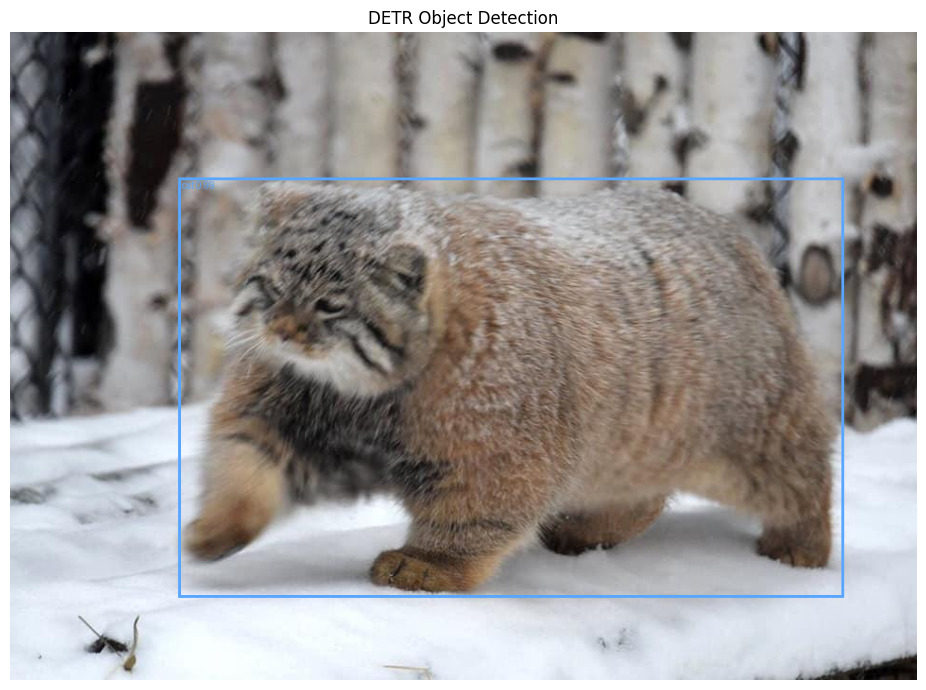

  ✅ Saved detection_result.png

🔄 HUGGINGFACE INTEROP

── Approach A: snapshot_download (works for models on ModelScope Hub) ──
  We already downloaded bert-base-uncased in Section 2: ./ms_cache/AI-ModelScope/bert-base-uncased

── Approach B: Direct HF loading (works globally for any HF model) ──


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  ✅ Loaded 'distilbert-base-uncased-finetuned-sst-2-english' directly from HuggingFace

── Manual inference without pipeline ──
  ✦ POSITIVE (0.9982): 'This open-source framework is a game changer for resear...'
  ✦ NEGATIVE (0.9994): 'I encountered multiple bugs during installation....'

── Loading Section 2's ModelScope-downloaded BERT with Transformers ──


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./ms_cache/AI-ModelScope/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  ✅ Training complete!
     Train loss: 0.4635
     Train time: 3138.6s

📊 MODEL EVALUATION



  Evaluation Results:
    eval_loss                : 0.3321
    eval_accuracy            : 0.8700
    eval_f1                  : 0.8700
    eval_runtime             : 191.2595
    eval_samples_per_second  : 2.6140
    eval_steps_per_second    : 0.0840
    epoch                    : 2.0000

  Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.88      0.86      0.87       254
    POSITIVE       0.86      0.88      0.87       246

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500



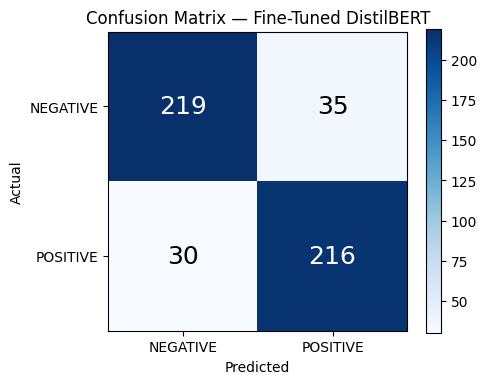

  ✅ Saved confusion_matrix.png

── Testing Fine-Tuned Model on New Inputs ──
  🟢 POSITIVE (0.8288): "An absolutely breathtaking masterpiece with brilliant performances!"
  🔴 NEGATIVE (0.8716): "Waste of two hours. Terrible script and wooden acting."
  🟢 POSITIVE (0.6575): "Decent popcorn movie but nothing special. Had some fun moments."

💾 EXPORTING THE FINE-TUNED MODEL



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✅ Model saved to: ./ms_finetuned_model/final
     Files: ['model.safetensors', 'tokenizer.json', 'config.json', 'training_args.bin', 'tokenizer_config.json']

── ONNX Export ──
  ⚠️  ONNX export skipped: No module named 'optimum.exporters.onnx'

── Upload to ModelScope Hub (manual step) ──

  1. Get a token from https://modelscope.cn/my/myaccesstoken
  2. Run:

     from modelscope.hub.api import HubApi
     api = HubApi()
     api.login('YOUR_TOKEN')
     api.push_model(
         model_id='your-username/my-finetuned-distilbert',
         model_dir='./ms_finetuned_model/final',
     )


╔══════════════════════════════════════════════════════════════════╗
║                   🎉  TUTORIAL COMPLETE!  🎉                    ║
╠══════════════════════════════════════════════════════════════════╣
║  ✓ ModelScope Hub — search, browse & download models            ║
║  ✓ MsDataset — load datasets from the ModelScope ecosystem      ║
║  ✓ NLP pipelines — sentiment, NER, zero-shot, generation, mask

In [4]:
print("\n📊 MODEL EVALUATION\n")

eval_results = trainer.evaluate()
print("  Evaluation Results:")
for key, value in eval_results.items():
    if isinstance(value, float):
        print(f"    {key:<25}: {value:.4f}")

from sklearn.metrics import classification_report, confusion_matrix

preds_output = trainer.predict(eval_ds)
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

print("\n  Classification Report:")
print(classification_report(labels, preds, target_names=["NEGATIVE", "POSITIVE"]))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["NEGATIVE", "POSITIVE"])
ax.set_yticklabels(["NEGATIVE", "POSITIVE"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Fine-Tuned DistilBERT")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=18)
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("  ✅ Saved confusion_matrix.png")

print("\n── Testing Fine-Tuned Model on New Inputs ──")
ft_pipeline = hf_pipeline(
    "sentiment-analysis",
    model=trainer.model,
    tokenizer=tokenizer,
    device=DEVICE,
)

new_reviews = [
    "An absolutely breathtaking masterpiece with brilliant performances!",
    "Waste of two hours. Terrible script and wooden acting.",
    "Decent popcorn movie but nothing special. Had some fun moments.",
]

for review in new_reviews:
    res = ft_pipeline(review)[0]
    emoji = "🟢" if res["label"] == "POSITIVE" else "🔴"
    print(f'  {emoji} {res["label"]} ({res["score"]:.4f}): "{review}"')


print("\n💾 EXPORTING THE FINE-TUNED MODEL\n")

save_path = "./ms_finetuned_model/final"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"  ✅ Model saved to: {save_path}")
print(f"     Files: {os.listdir(save_path)}")

print("\n── ONNX Export ──")
try:
    from optimum.exporters.onnx import main_export
    onnx_path = "./ms_finetuned_model/onnx"
    main_export(save_path, output=onnx_path, task="text-classification")
    print(f"  ✅ ONNX model exported to: {onnx_path}")
    print(f"     Files: {os.listdir(onnx_path)}")
except Exception as e:
    print(f"  ⚠️  ONNX export skipped: {e}")

print("""
── Upload to ModelScope Hub (manual step) ──

  1. Get a token from https://modelscope.cn/my/myaccesstoken
  2. Run:

     from modelscope.hub.api import HubApi
     api = HubApi()
     api.login('YOUR_TOKEN')
     api.push_model(
         model_id='your-username/my-finetuned-distilbert',
         model_dir='./ms_finetuned_model/final',
     )
""")

print("""
╔══════════════════════════════════════════════════════════════════╗
║                   🎉  TUTORIAL COMPLETE!  🎉                    ║
╠══════════════════════════════════════════════════════════════════╣
║  ✓ ModelScope Hub — search, browse & download models            ║
║  ✓ MsDataset — load datasets from the ModelScope ecosystem      ║
║  ✓ NLP pipelines — sentiment, NER, zero-shot, generation, mask  ║
║  ✓ CV pipelines — image classification, object detection, viz   ║
║  ✓ HuggingFace interop — snapshot_download + Transformers       ║
║  ✓ Fine-tuning — DistilBERT on IMDB with Trainer API            ║
║  ✓ Evaluation — accuracy, F1, confusion matrix                  ║
║  ✓ Export — local save, ONNX, Hub upload                        ║
╚══════════════════════════════════════════════════════════════════╝
""")